In [1]:
! pip install langchain langchain-groq langchain-huggingface langchain-community langchain-text-splitters langgraph python-dotenv faiss-cpu pypdf huggingface-hub sentence-transformers

In [2]:
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

/Users/pranshusama/Documents/LangGraph/myenv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import os
from transformers import logging as hf_logging

load_dotenv()
os.environ["HF_TOKEN"] = os.getenv("HUGGINGFACE_API_KEY", "")
hf_logging.set_verbosity_error()

In [4]:
llm = ChatGroq(model='llama-3.3-70b-versatile')

In [5]:
loader = PyPDFLoader("/Users/pranshusama/Downloads/intro-to-ml.pdf")
docs = loader.load()

In [6]:
len(docs)

392

In [7]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [8]:
len(chunks)

973

In [9]:
embeddings = HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2')
vector_store = FAISS.from_documents(chunks, embeddings)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6512.80it/s]


In [10]:
vector_store

In [11]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [12]:
retriever.invoke('What is Decision Tree?')

[Document(id='7134f5bd-9793-43db-a835-bf0f1429f53a', metadata={'producer': '3-Heights(TM) PDF Optimization Shell 5.9.1.5 (http://www.pdf-tools.com)', 'creator': 'AH CSS Formatter V6.2 MR4 for Linux64 : 6.2.6.18551 (2014/09/24 15:00JST)', 'creationdate': '2016-09-21T13:04:39+00:00', 'author': 'Andreas C. Müller and Sarah Guido', 'title': 'Introduction to Machine Learning with Python', 'trapped': '/False', 'moddate': '2020-08-19T07:09:16+02:00', 'source': '/Users/pranshusama/Downloads/intro-to-ml.pdf', 'total_pages': 392, 'page': 86, 'page_label': '73'}, page_content='Figure 2-24. Decision boundary of tree with depth 1 (left) and corresponding tree (right)\nFigure 2-25. Decision boundary of tree with depth 2 (left) and corresponding decision\ntree (right)\nThis recursive process yields a binary tree of decisions, with each node containing a\ntest. Alternatively, you can think of each test as splitting the part of the data that is\ncurrently being considered along one axis. This yields a

In [13]:
@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [14]:
tools = [rag_tool]
llm_with_tools = llm.bind_tools(tools)

In [15]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [16]:
def chat_node(state: ChatState):

    messages = state['messages']

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [17]:
tool_node = ToolNode(tools)

In [18]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

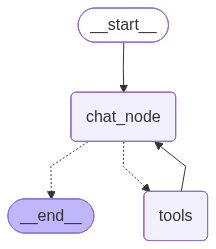

In [19]:
chatbot

In [24]:
result = chatbot.invoke(
    {
        "messages": [
            HumanMessage(
                content=(
                    "Using the pdf notes, explain how to split a node in decision tree?"
                )
            )
        ]
    }
)

In [25]:
print(result['messages'][-1].content)

To split a node in a decision tree, the algorithm searches over all possible tests and finds the one that is most informative about the target variable. The test is done by checking whether a feature is less than or equal to a certain value, and if the test is true, a point is assigned to the left node, otherwise it is assigned to the right node. This process is repeated until each region in the partition (each leaf in the decision tree) only contains a single target value (a single class or a single regression value). The decision tree is built by recursively partitioning the data into smaller subsets based on the tests in each node, with each node containing a test. The regions in the resulting partition always have axis-parallel boundaries. A prediction on a new data point is made by checking which region of the partition of the feature space the point lies in, and then predicting the majority target (or the single target in the case of pure leaves) in that region.
